# Baseline Erosion Model - Full Dataset (12,000+ Regions)

## 📖 Overview

This notebook applies the physics-based baseline erosion model to the complete dataset of 12,000+ scope regions from `wocu_output_fase2_20260210.gpkg`.

**How the Baseline Model Works:**
1. For each scope region, measure river bank distance from centerline at multiple time points (2017, 2022, 2025)
2. Calculate erosion velocity: Δdistance / Δtime
3. Take mean velocity as the "model" for that region
4. Predict future bank position: future_dist = last_dist + (velocity × years_ahead)

**Key Insight:** 
- Positive velocity = bank moving AWAY from river (erosion/retreat)
- Negative velocity = bank moving TOWARDS river (accretion/advance)

**Data Source:**
- Scope regions: `vlakken_scope` layer
- River bank points: `punten_oever` layer (with pre-calculated distance from centerline)
- Centerlines: `centrelines` layer
- Time snapshots: AHN3 (2017), AHN4 (2022), AHN5 (2025)

---

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, "../..")

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import TimestampedGeoJson
from pathlib import Path
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Project imports
import src.paths as PATHS
import src.constants as CONST
import src.legacy.model.baseline_model as BM
import src.legacy.data.config as DATA_CONFIG

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 10

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
# File paths
GPKG_PATH = PATHS.DATA_DIR / "01_raw/erosion/wocu_output_fase2_20260210.gpkg"

print(f"📂 Data source: {GPKG_PATH}")
print(f"   Exists: {GPKG_PATH.exists()}")

# Layers
SCOPE_LAYER = "vlakken_scope"
BANK_POINTS_LAYER = "punten_oever"
CENTERLINE_LAYER = "centrelines"
EROSION_POLYGONS_LAYER = "vlakken_erosie"

print(f"\n📋 Layers to use:")
print(f"   - {SCOPE_LAYER} (scope regions)")
print(f"   - {BANK_POINTS_LAYER} (river bank points with timestamps)")
print(f"   - {CENTERLINE_LAYER} (river centerlines)")

📂 Data source: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/01_raw/erosion/wocu_output_fase2_20260210.gpkg
   Exists: True

📋 Layers to use:
   - vlakken_scope (scope regions)
   - punten_oever (river bank points with timestamps)
   - centrelines (river centerlines)


## 2. Load Data

Loading all layers from the geopackage. This may take a minute for the large datasets.

In [6]:
%%time
print("📊 Loading scope regions...")
scope_regions = gpd.read_file(GPKG_PATH, layer=SCOPE_LAYER)
print(f"   ✅ Loaded {len(scope_regions):,} scope regions")
print(f"   Columns: {scope_regions.columns.tolist()}")
print(f"   CRS: {scope_regions.crs}")

📊 Loading scope regions...
   ✅ Loaded 12,130 scope regions
   Columns: ['position_id', 'waterlichaam', 'geometry']
   CRS: EPSG:28992
CPU times: user 36.2 ms, sys: 7.34 ms, total: 43.6 ms
Wall time: 51.4 ms


In [7]:
%%time
print("📍 Loading river bank points...")
bank_points = gpd.read_file(GPKG_PATH, layer=BANK_POINTS_LAYER)
print(f"   ✅ Loaded {len(bank_points):,} river bank points")
print(f"   Columns: {bank_points.columns.tolist()}")
print(f"\n   Key columns:")
print(f"      - location_id: {bank_points['location_id'].nunique():,} unique locations")
print(f"      - dtm_date: {sorted(bank_points['dtm_date'].unique())} (time snapshots)")
print(f"      - dist: distance from centerline [min={bank_points['dist'].min():.1f}, max={bank_points['dist'].max():.1f}]")
print(f"      - status: {bank_points['status'].value_counts().to_dict()}")

📍 Loading river bank points...
   ✅ Loaded 4,844,655 river bank points
   Columns: ['z', 'dist', 'type_oever', 'status', 'location_id', 'dtm_version', 'dtm_date', 'geometry']

   Key columns:
      - location_id: 10,487 unique locations
      - dtm_date: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)] (time snapshots)
      - dist: distance from centerline [min=0.8, max=348.6]
      - status: {'OK': 4078502, 'OUTLIER': 569299, 'UNCERTAIN': 196854}
CPU times: user 23.5 s, sys: 1.12 s, total: 24.6 s
Wall time: 25.3 s


In [8]:
print("🌊 Loading river centerlines...")
centerlines = gpd.read_file(GPKG_PATH, layer=CENTERLINE_LAYER)
print(f"   ✅ Loaded {len(centerlines)} centerline(s)")
print(f"   Total length: {centerlines.length.sum() / 1000:.1f} km")

🌊 Loading river centerlines...
   ✅ Loaded 12130 centerline(s)
   Total length: 1189.9 km


## 3. Data Quality Check

Quick sanity checks before processing.

In [9]:
print("🔍 Data Quality Checks\n" + "="*60)

# Check 1: Do all location_ids in bank_points exist in scope_regions?
bank_locations = set(bank_points['location_id'].unique())
scope_locations = set(scope_regions['location_id'].unique()) if 'location_id' in scope_regions.columns else set()

if scope_locations:
    in_both = bank_locations.intersection(scope_locations)
    only_in_banks = bank_locations - scope_locations
    only_in_scope = scope_locations - bank_locations
    
    print(f"\n✅ Location ID overlap:")
    print(f"   {len(in_both):,} locations in both datasets")
    print(f"   {len(only_in_banks):,} only in bank_points")
    print(f"   {len(only_in_scope):,} only in scope_regions")
else:
    print(f"\n⚠️ scope_regions doesn't have 'location_id' column")
    print(f"   Available columns: {scope_regions.columns.tolist()}")

# Check 2: Time coverage
print(f"\n📅 Time coverage:")
time_coverage = bank_points.groupby('location_id')['dtm_date'].nunique()
print(f"   Locations with 1 timestamp: {(time_coverage == 1).sum():,}")
print(f"   Locations with 2 timestamps: {(time_coverage == 2).sum():,}")
print(f"   Locations with 3+ timestamps: {(time_coverage >= 3).sum():,}")

# Check 3: Points per location
print(f"\n📍 Points per location per timestamp:")
points_per_location = bank_points.groupby(['location_id', 'dtm_date']).size()
print(f"   Mean: {points_per_location.mean():.1f}")
print(f"   Median: {points_per_location.median():.1f}")
print(f"   Min: {points_per_location.min()}")
print(f"   Max: {points_per_location.max()}")

🔍 Data Quality Checks

⚠️ scope_regions doesn't have 'location_id' column
   Available columns: ['position_id', 'waterlichaam', 'geometry']

📅 Time coverage:
   Locations with 1 timestamp: 144
   Locations with 2 timestamps: 929
   Locations with 3+ timestamps: 9,414

📍 Points per location per timestamp:
   Mean: 160.2
   Median: 170.0
   Min: 1
   Max: 660


In [18]:
print("🔗 Checking if position_id == location_id...\n")

# Check if position_id in scope_regions matches location_id in bank_points
if 'position_id' in scope_regions.columns:
    # Rename position_id to location_id for consistency
    scope_regions = scope_regions.rename(columns={'position_id': 'location_id'})
    print(f"✅ Renamed 'position_id' to 'location_id' in scope_regions")
    print(f"   Updated columns: {scope_regions.columns.tolist()}")
    
    # Now check the overlap
    bank_locations = set(bank_points['location_id'].unique())
    scope_locations = set(scope_regions['location_id'].unique())
    
    in_both = bank_locations.intersection(scope_locations)
    only_in_banks = bank_locations - scope_locations
    only_in_scope = scope_locations - bank_locations
    
    print(f"\n✅ Location ID overlap:")
    print(f"   {len(in_both):,} locations in both datasets")
    print(f"   {len(only_in_banks):,} only in bank_points")
    print(f"   {len(only_in_scope):,} only in scope_regions")
    
    if len(only_in_banks) > 0:
        print(f"\n💡 Note: {len(only_in_banks):,} locations have bank data but no scope region geometry")
        print(f"   These can still be used for modeling, just not for map visualization")
else:
    print(f"⚠️ scope_regions doesn't have 'position_id' either!")
    print(f"   Available columns: {scope_regions.columns.tolist()}")

🔗 Checking if position_id == location_id...

✅ Renamed 'position_id' to 'location_id' in scope_regions
   Updated columns: ['location_id', 'waterlichaam', 'geometry']

✅ Location ID overlap:
   10,487 locations in both datasets
   0 only in bank_points
   1,643 only in scope_regions


## 4. Process Erosion Data

Convert raw bank points into the format needed for the baseline model:
- Group by location_id and timestamp
- Calculate mean distance from centerline per location per year
- Create multi-index dataframe with (location_id, timestamp) → distance

In [10]:
%%time
print("🔄 Processing erosion data...\n")

# Filter for quality points if needed
print(f"Original points: {len(bank_points):,}")

# Optional: filter by status (e.g., only use 'OK' points)
# For now, let's use all points but you can uncomment this:
# bank_points_filtered = bank_points[bank_points['status'] == 'OK'].copy()
bank_points_filtered = bank_points.copy()

print(f"Filtered points: {len(bank_points_filtered):,}")

# Calculate mean distance per location per timestamp
processed_erosion_data = bank_points_filtered.groupby(['location_id', 'dtm_date']).agg({
    'dist': 'mean',  # Mean distance from centerline
    'z': 'mean'      # Mean elevation (for reference)
}).rename(columns={'dist': 'distance_to_erosion_border'})  # Rename to match baseline model expectations

print(f"\n✅ Processed erosion data:")
print(f"   Shape: {processed_erosion_data.shape}")
print(f"   Unique locations: {processed_erosion_data.index.get_level_values(0).nunique():,}")
print(f"   Time range: {processed_erosion_data.index.get_level_values(1).min()} - {processed_erosion_data.index.get_level_values(1).max()}")

print(f"\n📊 Sample data:")
print(processed_erosion_data.head(10))

🔄 Processing erosion data...

Original points: 4,844,655
Filtered points: 4,844,655

✅ Processed erosion data:
   Shape: (30244, 2)
   Unique locations: 10,487
   Time range: 2015 - 2025

📊 Sample data:
                              distance_to_erosion_border          z
location_id         dtm_date                                       
ijssel1_l_0000_0010 2017                      135.318584  10.300309
                    2025                      129.991870  10.279232
ijssel1_l_0010_0020 2017                      136.334927   9.856534
                    2022                      141.877393   9.976304
                    2025                      138.252841   9.978651
ijssel1_l_0020_0030 2017                      153.443089  10.367583
                    2022                      155.134956  10.399406
                    2025                      153.908416  10.364936
ijssel1_l_0050_0056 2017                       43.671610  10.145825
                    2022                       43

## 5. Configure and Train Baseline Model

Set up the configuration and train the baseline model on all regions.

In [11]:
# Create configuration
baseline_config = DATA_CONFIG.DataConfiguration(
    prediction_region_id_column_name='location_id',
    timestamp_column_name='dtm_date',
    no_of_points_for_distance_calculation=3
)

print("⚙️ Configuration:")
print(f"   prediction_region_id_column_name: {baseline_config.prediction_region_id_column_name}")
print(f"   timestamp_column_name: {baseline_config.timestamp_column_name}")
print(f"   no_of_points_for_distance_calculation: {baseline_config.no_of_points_for_distance_calculation}")

⚙️ Configuration:
   prediction_region_id_column_name: location_id
   timestamp_column_name: dtm_date
   no_of_points_for_distance_calculation: 3


In [12]:
%%time
print("🚀 Training baseline model...\n")

# Initialize model
baseline_model = BM.BaselineErosionModel(
    config=baseline_config,
    training_data=processed_erosion_data,
    verbose=False  # Set to True to see per-region training messages
)

# Train
baseline_model.train()

print(f"\n✅ Model trained!")
print(f"   Trained on {len(baseline_model.model):,} regions")
print(f"\n📊 Erosion velocity statistics (m/year):")
velocities = pd.Series(baseline_model.model)
print(f"   Mean: {velocities.mean():.4f}")
print(f"   Median: {velocities.median():.4f}")
print(f"   Std: {velocities.std():.4f}")
print(f"   Min: {velocities.min():.4f}")
print(f"   Max: {velocities.max():.4f}")
print(f"\n   Regions with erosion (positive velocity): {(velocities > 0).sum():,} ({(velocities > 0).sum() / len(velocities) * 100:.1f}%)")
print(f"   Regions with accretion (negative velocity): {(velocities < 0).sum():,} ({(velocities < 0).sum() / len(velocities) * 100:.1f}%)")
print(f"   Regions stable (zero velocity): {(velocities == 0).sum():,}")

🚀 Training baseline model...


✅ Model trained!
   Trained on 10,487 regions

📊 Erosion velocity statistics (m/year):
   Mean: 0.2648
   Median: 0.0326
   Std: 1.8634
   Min: -28.8219
   Max: 29.1777

   Regions with erosion (positive velocity): 6,090 (58.1%)
   Regions with accretion (negative velocity): 4,253 (40.6%)
   Regions stable (zero velocity): 0
CPU times: user 4.31 s, sys: 64.7 ms, total: 4.38 s
Wall time: 4.47 s


## 6. Visualize Erosion Velocities

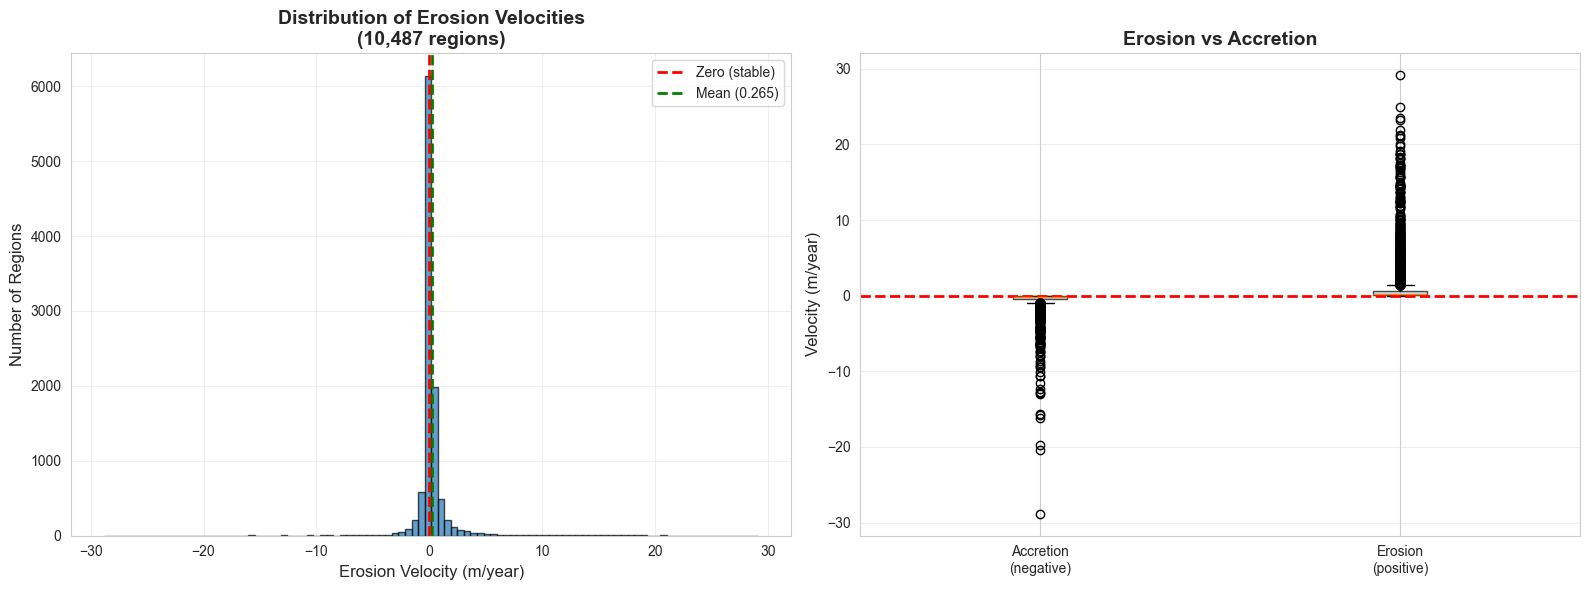


📈 Interpretation:
   Positive velocity → Bank moving AWAY from river (erosion/inland retreat)
   Negative velocity → Bank moving TOWARD river (accretion/advance)
   Zero velocity → Stable bank


In [13]:
# Distribution of erosion velocities
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(velocities, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (stable)')
axes[0].axvline(velocities.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean ({velocities.mean():.3f})')
axes[0].set_xlabel('Erosion Velocity (m/year)', fontsize=12)
axes[0].set_ylabel('Number of Regions', fontsize=12)
axes[0].set_title(f'Distribution of Erosion Velocities\n({len(velocities):,} regions)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot([velocities[velocities < 0], velocities[velocities > 0]], 
                labels=['Accretion\n(negative)', 'Erosion\n(positive)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_ylabel('Velocity (m/year)', fontsize=12)
axes[1].set_title('Erosion vs Accretion', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📈 Interpretation:")
print(f"   Positive velocity → Bank moving AWAY from river (erosion/inland retreat)")
print(f"   Negative velocity → Bank moving TOWARD river (accretion/advance)")
print(f"   Zero velocity → Stable bank")

## 7. Make Predictions

Predict future bank positions for different time horizons.

In [15]:
# Prediction horizons (years into the future)
PREDICTION_HORIZONS = [1, 5, 10, 20]

print("🔮 Making predictions...\n")

predictions = {}
for horizon in PREDICTION_HORIZONS:
    pred = baseline_model.predict(processed_erosion_data, prediction_length=horizon)
    predictions[horizon] = pred
    print(f"   ✅ {horizon} year(s) ahead: {len(pred):,} predictions")

print(f"\n📊 Sample predictions (first location):")
sample_location = processed_erosion_data.index.get_level_values(0)[0]
sample_data = processed_erosion_data.loc[sample_location]
print(f"\nLocation: {sample_location}")
print(f"\nHistorical data:")
print(sample_data)
print(f"\nPredictions:")
for horizon in PREDICTION_HORIZONS:
    if sample_location in predictions[horizon].index.get_level_values(0):
        # The predict method returns columns named: future_distance_to_erosion_border_{step}
        pred_col = f'future_distance_to_erosion_border_{horizon}'
        pred_value = predictions[horizon].loc[sample_location, pred_col].iloc[-1]
        print(f"   {horizon} year(s): {pred_value:.2f} m from centerline")

🔮 Making predictions...

   ✅ 1 year(s) ahead: 30,244 predictions
   ✅ 5 year(s) ahead: 30,244 predictions
   ✅ 10 year(s) ahead: 30,244 predictions
   ✅ 20 year(s) ahead: 30,244 predictions

📊 Sample predictions (first location):

Location: ijssel1_l_0000_0010

Historical data:
          distance_to_erosion_border          z
dtm_date                                       
2017                      135.318584  10.300309
2025                      129.991870  10.279232

Predictions:
   1 year(s): 129.33 m from centerline
   5 year(s): 126.66 m from centerline
   10 year(s): 123.33 m from centerline
   20 year(s): 116.68 m from centerline


## 8. Aggregate Statistics & Summary

Overall performance and insights across all regions.

In [16]:
print("="*80)
print("BASELINE MODEL SUMMARY")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   Total scope regions: {len(scope_regions):,}")
print(f"   Regions with erosion data: {len(baseline_model.model):,}")
print(f"   Time snapshots: {sorted(bank_points['dtm_date'].unique())}")
print(f"   Total bank points: {len(bank_points):,}")

print(f"\n🚀 Model Results:")
print(f"   Mean erosion velocity: {velocities.mean():.4f} m/year")
print(f"   Median erosion velocity: {velocities.median():.4f} m/year")

# Classify regions by erosion severity
severe_erosion = velocities[velocities > 0.5].count()
moderate_erosion = velocities[(velocities > 0.1) & (velocities <= 0.5)].count()
mild_erosion = velocities[(velocities > 0) & (velocities <= 0.1)].count()
stable = velocities[velocities == 0].count()
mild_accretion = velocities[(velocities < 0) & (velocities >= -0.1)].count()
moderate_accretion = velocities[(velocities < -0.1) & (velocities >= -0.5)].count()
severe_accretion = velocities[velocities < -0.5].count()

print(f"\n📈 Classification:")
print(f"   Severe erosion (>0.5 m/yr): {severe_erosion:,} ({severe_erosion/len(velocities)*100:.1f}%)")
print(f"   Moderate erosion (0.1-0.5 m/yr): {moderate_erosion:,} ({moderate_erosion/len(velocities)*100:.1f}%)")
print(f"   Mild erosion (0-0.1 m/yr): {mild_erosion:,} ({mild_erosion/len(velocities)*100:.1f}%)")
print(f"   Stable (0 m/yr): {stable:,} ({stable/len(velocities)*100:.1f}%)")
print(f"   Mild accretion (-0.1-0 m/yr): {mild_accretion:,} ({mild_accretion/len(velocities)*100:.1f}%)")
print(f"   Moderate accretion (-0.5--0.1 m/yr): {moderate_accretion:,} ({moderate_accretion/len(velocities)*100:.1f}%)")
print(f"   Severe accretion (<-0.5 m/yr): {severe_accretion:,} ({severe_accretion/len(velocities)*100:.1f}%)")

print(f"\n🔮 10-year predictions:")
pred_10yr = predictions[10]
# Calculate how much bank will move in 10 years
velocities_series = pd.Series(baseline_model.model)
movement_10yr = velocities_series * 10
print(f"   Mean predicted movement: {movement_10yr.mean():.2f} m")
print(f"   Max erosion: {movement_10yr.max():.2f} m (bank retreats inland)")
print(f"   Max accretion: {movement_10yr.min():.2f} m (bank advances toward river)")

BASELINE MODEL SUMMARY

📊 Dataset:
   Total scope regions: 12,130
   Regions with erosion data: 10,487
   Time snapshots: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)]
   Total bank points: 4,844,655

🚀 Model Results:
   Mean erosion velocity: 0.2648 m/year
   Median erosion velocity: 0.0326 m/year

📈 Classification:
   Severe erosion (>0.5 m/yr): 1,683 (16.0%)
   Moderate erosion (0.1-0.5 m/yr): 2,326 (22.2%)
   Mild erosion (0-0.1 m/yr): 2,081 (19.8%)
   Stable (0 m/yr): 0 (0.0%)
   Mild accretion (-0.1-0 m/yr): 1,844 (17.6%)
   Moderate accretion (-0.5--0.1 m/yr): 1,538 (14.7%)
   Severe accretion (<-0.5 m/yr): 871 (8.3%)

🔮 10-year predictions:
   Mean predicted movement: 2.65 m
   Max erosion: 291.78 m (bank retreats inland)
   Max accretion: -288.22 m (bank advances toward river)


## 9. Map Visualization (Sample)

⚠️ **Note:** Visualizing all 12,000+ regions would be too heavy for an interactive notebook map. 
Let's visualize a sample of ~100-500 regions to demonstrate the results.

For full-scale visualization, consider:
- Export to GeoPackage and view in QGIS
- Build a React frontend with tile-based rendering
- Use aggregated heatmaps

In [19]:
# Sample regions for visualization
SAMPLE_SIZE = 200  # Adjust based on performance

# Sample regions with diverse erosion rates
velocities_df = velocities.reset_index()
velocities_df.columns = ['location_id', 'velocity']

# Sample from different velocity bins
sample_severe_erosion = velocities_df[velocities_df['velocity'] > 0.5].sample(n=min(20, (velocities_df['velocity'] > 0.5).sum()), random_state=42) if (velocities_df['velocity'] > 0.5).any() else pd.DataFrame()
sample_moderate = velocities_df[(velocities_df['velocity'] > -0.5) & (velocities_df['velocity'] <= 0.5)].sample(n=min(150, len(velocities_df[(velocities_df['velocity'] > -0.5) & (velocities_df['velocity'] <= 0.5)])), random_state=42)
sample_severe_accretion = velocities_df[velocities_df['velocity'] < -0.5].sample(n=min(20, (velocities_df['velocity'] < -0.5).sum()), random_state=42) if (velocities_df['velocity'] < -0.5).any() else pd.DataFrame()

sample_locations = pd.concat([sample_severe_erosion, sample_moderate, sample_severe_accretion])['location_id'].tolist()

print(f"📍 Sampling {len(sample_locations)} regions for map visualization")
print(f"   (Full dataset has {len(velocities):,} regions)")

# Get sample scope regions
if 'location_id' in scope_regions.columns:
    sample_scope = scope_regions[scope_regions['location_id'].isin(sample_locations)].copy()
    sample_scope = sample_scope.merge(velocities_df, on='location_id', how='left')
    print(f"   ✅ Matched {len(sample_scope)} regions with geometry")
else:
    print(f"   ⚠️ Cannot create map: scope_regions missing 'location_id' column")
    sample_scope = None

📍 Sampling 190 regions for map visualization
   (Full dataset has 10,487 regions)
   ✅ Matched 190 regions with geometry


In [22]:
if sample_scope is not None and len(sample_scope) > 0:
    # Create map
    print("🗺️ Creating interactive map...\n")
    
    # Convert to WGS84 for folium
    sample_scope_wgs84 = sample_scope.to_crs(epsg=4326)
    centerlines_wgs84 = centerlines.to_crs(epsg=4326)
    
    # Get center point
    center_lat = sample_scope_wgs84.geometry.centroid.y.mean()
    center_lon = sample_scope_wgs84.geometry.centroid.x.mean()
    
    # Create map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='OpenStreetMap'
    )
    
    # Add centerlines
    folium.GeoJson(
        centerlines_wgs84,
        name='River Centerline',
        style_function=lambda x: {
            'color': 'blue',
            'weight': 3,
            'opacity': 0.7
        }
    ).add_to(m)
    
    # Add scope regions colored by erosion velocity
    # Define color scale: red = erosion, green = accretion
    def get_color(velocity):
        if velocity > 0.5:
            return '#d73027'  # Dark red - severe erosion
        elif velocity > 0.1:
            return '#fc8d59'  # Orange - moderate erosion
        elif velocity > 0:
            return '#fee090'  # Light yellow - mild erosion
        elif velocity == 0:
            return '#ffffbf'  # Yellow - stable
        elif velocity > -0.1:
            return '#e0f3f8'  # Light blue - mild accretion
        elif velocity > -0.5:
            return '#91bfdb'  # Blue - moderate accretion
        else:
            return '#4575b4'  # Dark blue - severe accretion
    
    for idx, row in sample_scope_wgs84.iterrows():
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, vel=row['velocity']: {
                'fillColor': get_color(vel),
                'color': 'black',
                'weight': 1,
                'fillOpacity': 0.6
            },
            tooltip=f"Location: {row['location_id']}<br>Velocity: {row['velocity']:.3f} m/yr"
        ).add_to(m)
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 200px; height: 220px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <p style="margin:0; font-weight:bold">Erosion Velocity (m/yr)</p>
    <p style="margin:2px"><span style="background-color:#d73027; padding:2px 10px">&nbsp;</span> >0.5 (severe erosion)</p>
    <p style="margin:2px"><span style="background-color:#fc8d59; padding:2px 10px">&nbsp;</span> 0.1-0.5 (moderate erosion)</p>
    <p style="margin:2px"><span style="background-color:#fee090; padding:2px 10px">&nbsp;</span> 0-0.1 (mild erosion)</p>
    <p style="margin:2px"><span style="background-color:#ffffbf; padding:2px 10px">&nbsp;</span> 0 (stable)</p>
    <p style="margin:2px"><span style="background-color:#e0f3f8; padding:2px 10px">&nbsp;</span> -0.1-0 (mild accretion)</p>
    <p style="margin:2px"><span style="background-color:#91bfdb; padding:2px 10px">&nbsp;</span> -0.5--0.1 (moderate accretion)</p>
    <p style="margin:2px"><span style="background-color:#4575b4; padding:2px 10px">&nbsp;</span> <-0.5 (severe accretion)</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    folium.LayerControl().add_to(m)
    
    print(f"✅ Map created with {len(sample_scope)} regions")
    print(f"\n💡 Tip: Hover over regions to see erosion velocity")
    print(f"   Red = erosion (bank retreating), Blue = accretion (bank advancing)")
    
    display(m)
else:
    print("⚠️ Cannot create map - no sample data available")

🗺️ Creating interactive map...

✅ Map created with 190 regions

💡 Tip: Hover over regions to see erosion velocity
   Red = erosion (bank retreating), Blue = accretion (bank advancing)


## 9. Animated Time-Based Visualization

Create an interactive map showing how erosion evolves over time with predictions into the future.

In [ ]:
if sample_scope is not None and len(sample_scope) > 0:
    print("🎬 Creating animated time-based visualization...\n")
    
    # Convert to WGS84
    sample_scope_wgs84 = sample_scope.to_crs(epsg=4326)
    centerlines_wgs84 = centerlines.to_crs(epsg=4326)
    
    # Get center point
    center_lat = sample_scope_wgs84.geometry.centroid.y.mean()
    center_lon = sample_scope_wgs84.geometry.centroid.x.mean()
    
    # Create base map
    m_animated = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='OpenStreetMap',
        control_scale=True
    )
    
    # Add centerlines (static)
    folium.GeoJson(
        centerlines_wgs84,
        name='River Centerline',
        style_function=lambda x: {
            'color': 'blue',
            'weight': 3,
            'opacity': 0.7
        }
    ).add_to(m_animated)
    
    # Create time-based features for predictions
    # We'll show the historical data + predictions at different time points
    time_points = [2017, 2025, 2026, 2030, 2035, 2045]  # Historical + future
    
    geojson_features = []
    
    for _, row in sample_scope_wgs84.iterrows():
        location_id = row['location_id']
        velocity = row['velocity']
        
        # Get historical distances
        if location_id in processed_erosion_data.index.get_level_values(0):
            historical_data = processed_erosion_data.loc[location_id]
            
            # Get last known distance (2025)
            if 2025 in historical_data.index.get_level_values(0):
                last_distance = historical_data.loc[2025, 'distance_to_erosion_border']
            elif len(historical_data) > 0:
                last_distance = historical_data['distance_to_erosion_border'].iloc[-1]
            else:
                continue
            
            # Create features for each time point
            for year in time_points:
                if year <= 2025:
                    # Historical data
                    if year in historical_data.index.get_level_values(0):
                        distance = historical_data.loc[year, 'distance_to_erosion_border']
                        is_prediction = False
                    else:
                        continue
                else:
                    # Future prediction
                    years_ahead = year - 2025
                    distance = last_distance + (velocity * years_ahead)
                    is_prediction = True
                
                # Color based on velocity
                if velocity > 0.5:
                    color = '#d73027'  # Severe erosion
                elif velocity > 0.1:
                    color = '#fc8d59'  # Moderate erosion
                elif velocity > 0:
                    color = '#fee090'  # Mild erosion
                elif velocity == 0:
                    color = '#ffffbf'  # Stable
                elif velocity > -0.1:
                    color = '#e0f3f8'  # Mild accretion
                elif velocity > -0.5:
                    color = '#91bfdb'  # Moderate accretion
                else:
                    color = '#4575b4'  # Severe accretion
                
                # Adjust opacity for predictions
                opacity = 0.4 if is_prediction else 0.7
                
                feature = {
                    "type": "Feature",
                    "geometry": row.geometry.__geo_interface__,
                    "properties": {
                        "times": [f"{year}-01-01T00:00:00"],
                        "style": {
                            "color": "black",
                            "fillColor": color,
                            "fillOpacity": opacity,
                            "weight": 1
                        },
                        "popup": f"<b>{location_id}</b><br>"
                                f"Year: {year}<br>"
                                f"Velocity: {velocity:.3f} m/yr<br>"
                                f"Distance: {distance:.1f} m<br>"
                                f"{'(Predicted)' if is_prediction else '(Historical)'}"
                    }
                }
                geojson_features.append(feature)
    
    # Create GeoJSON FeatureCollection
    geojson_data = {
        "type": "FeatureCollection",
        "features": geojson_features
    }
    
    # Add TimestampedGeoJson layer
    TimestampedGeoJson(
        geojson_data,
        period="P1Y",  # Period between timestamps (1 year)
        duration="P1Y",  # How long each frame is displayed
        transition_time=500,  # Milliseconds between frames
        loop=True,  # Loop animation
        auto_play=False,  # Don't start automatically
        loop_button=True,  # Show loop control
        date_options="YYYY",  # Display format
        time_slider_drag_update=True
    ).add_to(m_animated)
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; right: 50px; width: 250px; height: 280px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <p style="margin:0; font-weight:bold">🎬 Erosion Animation</p>
    <p style="margin:5px 0; font-size:12px">Historical (2017-2025) + Predictions (2026-2045)</p>
    <hr style="margin:5px 0">
    <p style="margin:0; font-weight:bold">Velocity (m/yr)</p>
    <p style="margin:2px"><span style="background-color:#d73027; padding:2px 10px">&nbsp;</span> >0.5 (severe erosion)</p>
    <p style="margin:2px"><span style="background-color:#fc8d59; padding:2px 10px">&nbsp;</span> 0.1-0.5 (moderate)</p>
    <p style="margin:2px"><span style="background-color:#fee090; padding:2px 10px">&nbsp;</span> 0-0.1 (mild)</p>
    <p style="margin:2px"><span style="background-color:#ffffbf; padding:2px 10px">&nbsp;</span> 0 (stable)</p>
    <p style="margin:2px"><span style="background-color:#e0f3f8; padding:2px 10px">&nbsp;</span> -0.1-0 (mild accretion)</p>
    <p style="margin:2px"><span style="background-color:#91bfdb; padding:2px 10px">&nbsp;</span> -0.5--0.1 (moderate)</p>
    <p style="margin:2px"><span style="background-color:#4575b4; padding:2px 10px">&nbsp;</span> <-0.5 (severe)</p>
    </div>
    '''
    m_animated.get_root().html.add_child(folium.Element(legend_html))
    
    folium.LayerControl().add_to(m_animated)
    
    print(f"✅ Animated map created with {len(sample_scope)} regions")
    print(f"   Time range: 2017-2045 (historical + predictions)")
    print(f"\n💡 Tip: Use the time slider at the top to see erosion evolution")
    print(f"   • 2017-2025: Historical measurements (darker)")
    print(f"   • 2026-2045: Model predictions (lighter)")
    print(f"   • Press play ▶️ to start the animation")
    
    display(m_animated)
else:
    print("⚠️ Cannot create animated map - no sample data available")

## 10. Export Results

Save predictions and model results for further analysis or visualization in other tools.

In [ ]:
# Create output directory
OUTPUT_DIR = PATHS.DATA_DIR / "04_model_outputs"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"💾 Exporting results to: {OUTPUT_DIR}\n")

# 1. Export velocities with geometries
if 'location_id' in scope_regions.columns:
    velocities_geo = scope_regions.merge(velocities_df, on='location_id', how='left')
    output_path_gpkg = OUTPUT_DIR / "baseline_model_velocities.gpkg"
    velocities_geo.to_file(output_path_gpkg, driver='GPKG', layer='erosion_velocities')
    print(f"   ✅ Saved velocities with geometry: {output_path_gpkg}")
    print(f"      ({len(velocities_geo):,} regions)")

# 2. Export predictions CSV
for horizon in PREDICTION_HORIZONS:
    output_path_csv = OUTPUT_DIR / f"predictions_{horizon}yr.csv"
    predictions[horizon].to_csv(output_path_csv)
    print(f"   ✅ Saved {horizon}-year predictions: {output_path_csv}")

# 3. Save model (pickle)
import pickle
model_path = OUTPUT_DIR / "baseline_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(baseline_model, f)
print(f"   ✅ Saved trained model: {model_path}")

print(f"\n✅ All results exported!")

## 🎯 Next Steps

**For better visualization of 12,000+ regions:**
1. Open `baseline_model_velocities.gpkg` in QGIS
2. Style by `velocity` column with graduated colors
3. Consider building a React frontend with:
   - Tile-based rendering (e.g., MapLibre GL JS)
   - Vector tiles for performance
   - Aggregated heatmaps for overview
   - Detail view on click

**For model improvement:**
1. Add features (water levels, discharge, soil type, vegetation)
2. Train ML model (LSTM, Random Forest) using baseline as benchmark
3. Validate predictions against 2025 data (train on 2017-2022, test on 2025)
4. Ensemble multiple models